# Phase 4: Exploratory Data Analysis & Visualisation

**Goal:** Uncover insights, patterns, and trends through comprehensive data exploration and visualisation

**Tools:** Python, Pandas, Matplotlib, Seaborn, Statistical Analysis

**Context:** We have ML models from Phase 3. Now let's deeply understand the data and validate our findings.

---

## Table of Contents
- [Step 1: Customer Analysis & Behavior Patterns](#Step-1)
- [Step 2: Revenue & Sales Trends Analysis](#Step-2)
- [Step 3: Product Performance Analysis](#Step-3)
- [Step 4: Statistical Analysis & Correlations](#Step-4)
- [Step 5: Executive Summary & Insights Report](#Step-5)

---

## Setup & Data Loading

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import sqlite3
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visualisation settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette("husl")

print(" All libraries imported!")

 All libraries imported!


In [3]:
# Load data from database
conn = sqlite3.connect('ecommerce.db')

# Load tables
customers = pd.read_sql_query("SELECT * FROM customers", conn)
products = pd.read_sql_query("SELECT * FROM products", conn)
invoices = pd.read_sql_query("SELECT * FROM invoices", conn)
invoice_items = pd.read_sql_query("SELECT * FROM invoice_items", conn)

# Load feature data from Week 2
customer_features = pd.read_csv('customer_features_reduced.csv')

# Load churn predictions from Week 3 (if available)
try:
    churn_predictions = pd.read_csv('customer_churn_predictions.csv')
    has_predictions = True
    print(" Churn predictions loaded")
except:
    has_predictions = False
    print(" No churn predictions found (optional)")

# Convert dates
invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'])
customers['first_purchase_date'] = pd.to_datetime(customers['first_purchase_date'])
customers['last_purchase_date'] = pd.to_datetime(customers['last_purchase_date'])

print(f"\n Data Loaded:")
print(f"   • Customers: {len(customers):,}")
print(f"   • Products: {len(products):,}")
print(f"   • Invoices: {len(invoices):,}")
print(f"   • Invoice Items: {len(invoice_items):,}")
print(f"   • Customer Features: {len(customer_features):,}")

 Churn predictions loaded

 Data Loaded:
   • Customers: 4,367
   • Products: 3,684
   • Invoices: 22,178
   • Invoice Items: 406,545
   • Customer Features: 4,315


---
<a id='Step-1'></a>
# Step 1: Customer Analysis & Behaviour Patterns

## Objectives:
- Analyse customer distribution by geography
- Examine purchase frequency patterns
- Identify high-value vs. low-value segments
- Analyse customer cohorts
- Statistical summaries of customer metrics

## 1.1 Geographic Distribution

GEOGRAPHIC CUSTOMER DISTRIBUTION

 Top 15 Countries by Customer Count:
    1. United Kingdom      : 3,949 customers ( 90.4%)
    2. Germany             :   95 customers (  2.2%)
    3. France              :   87 customers (  2.0%)
    4. Spain               :   29 customers (  0.7%)
    5. Belgium             :   24 customers (  0.5%)
    6. Switzerland         :   20 customers (  0.5%)
    7. Portugal            :   19 customers (  0.4%)
    8. Italy               :   15 customers (  0.3%)
    9. Finland             :   12 customers (  0.3%)
   10. Norway              :   10 customers (  0.2%)
   11. Austria             :    9 customers (  0.2%)
   12. Australia           :    9 customers (  0.2%)
   13. Netherlands         :    9 customers (  0.2%)
   14. Channel Islands     :    9 customers (  0.2%)
   15. Denmark             :    8 customers (  0.2%)


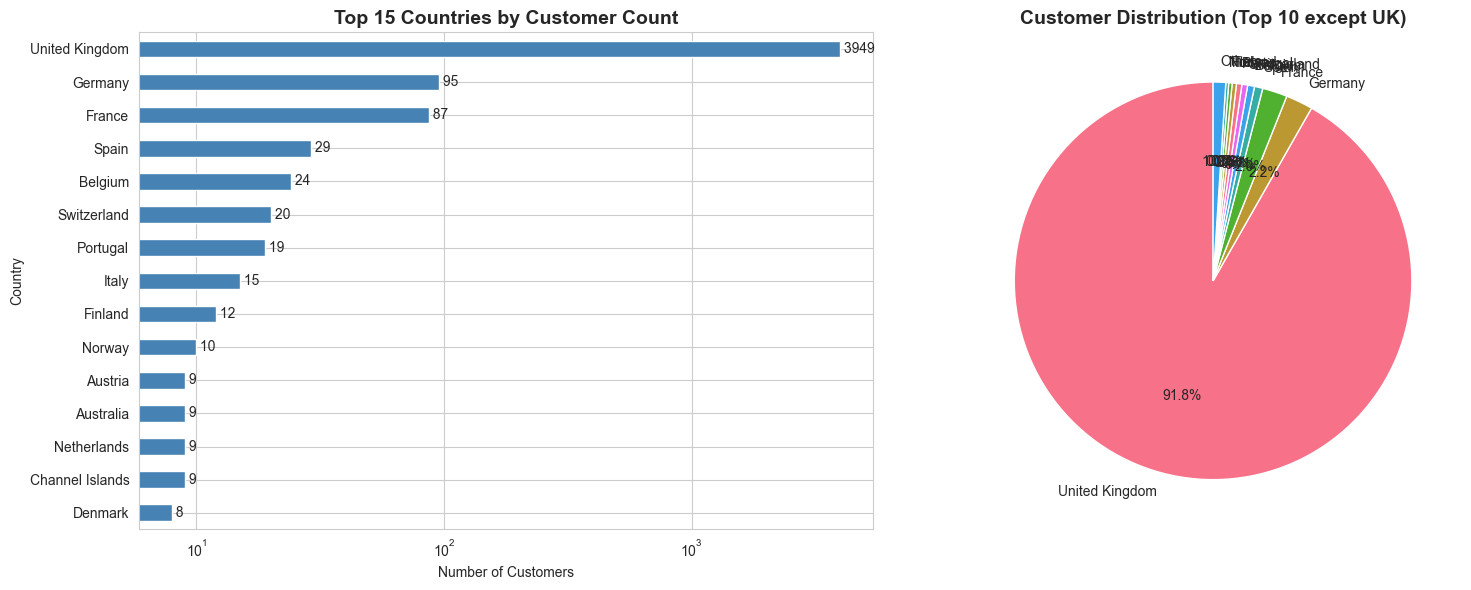


 Key Insight: United Kingdom represents 90.4% of customer base


In [4]:
print("="*60)
print("GEOGRAPHIC CUSTOMER DISTRIBUTION")
print("="*60)

# Customer count by country
country_dist = customers['country'].value_counts().head(15)

print("\n Top 15 Countries by Customer Count:")
for i, (country, count) in enumerate(country_dist.items(), 1):
    pct = count / len(customers) * 100
    print(f"   {i:2d}. {country:20s}: {count:4,} customers ({pct:5.1f}%)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
country_dist.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xscale('log')   # Because UK is by far dominating, so we need to visualise the graph in a better manner
axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('Country')
axes[0].set_title('Top 15 Countries by Customer Count', fontweight='bold', fontsize=14)
axes[0].invert_yaxis()

# Pie chart for top 10
top10_countries = country_dist.head(10)#.iloc[1:]
others = country_dist.iloc[10:].sum()
pie_data = pd.concat([top10_countries, pd.Series({'Others': others})])
axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Customer Distribution (Top 10 except UK)', fontweight='bold', fontsize=14)

# Add value labels next to bars
for i, v in enumerate(country_dist):
    axes[0].text(v, i, f' {v}', va='center')
    

plt.tight_layout()
plt.savefig('customer_geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Key Insight: {country_dist.index[0]} represents {country_dist.iloc[0]/len(customers)*100:.1f}% of customer base")

GEOGRAPHIC CUSTOMER DISTRIBUTION

 Top 15 Countries by Customer Count:
    1. United Kingdom      : 3,949 customers ( 90.4%)
    2. Germany             :   95 customers (  2.2%)
    3. France              :   87 customers (  2.0%)
    4. Spain               :   29 customers (  0.7%)
    5. Belgium             :   24 customers (  0.5%)
    6. Switzerland         :   20 customers (  0.5%)
    7. Portugal            :   19 customers (  0.4%)
    8. Italy               :   15 customers (  0.3%)
    9. Finland             :   12 customers (  0.3%)
   10. Norway              :   10 customers (  0.2%)
   11. Austria             :    9 customers (  0.2%)
   12. Australia           :    9 customers (  0.2%)
   13. Netherlands         :    9 customers (  0.2%)
   14. Channel Islands     :    9 customers (  0.2%)
   15. Denmark             :    8 customers (  0.2%)


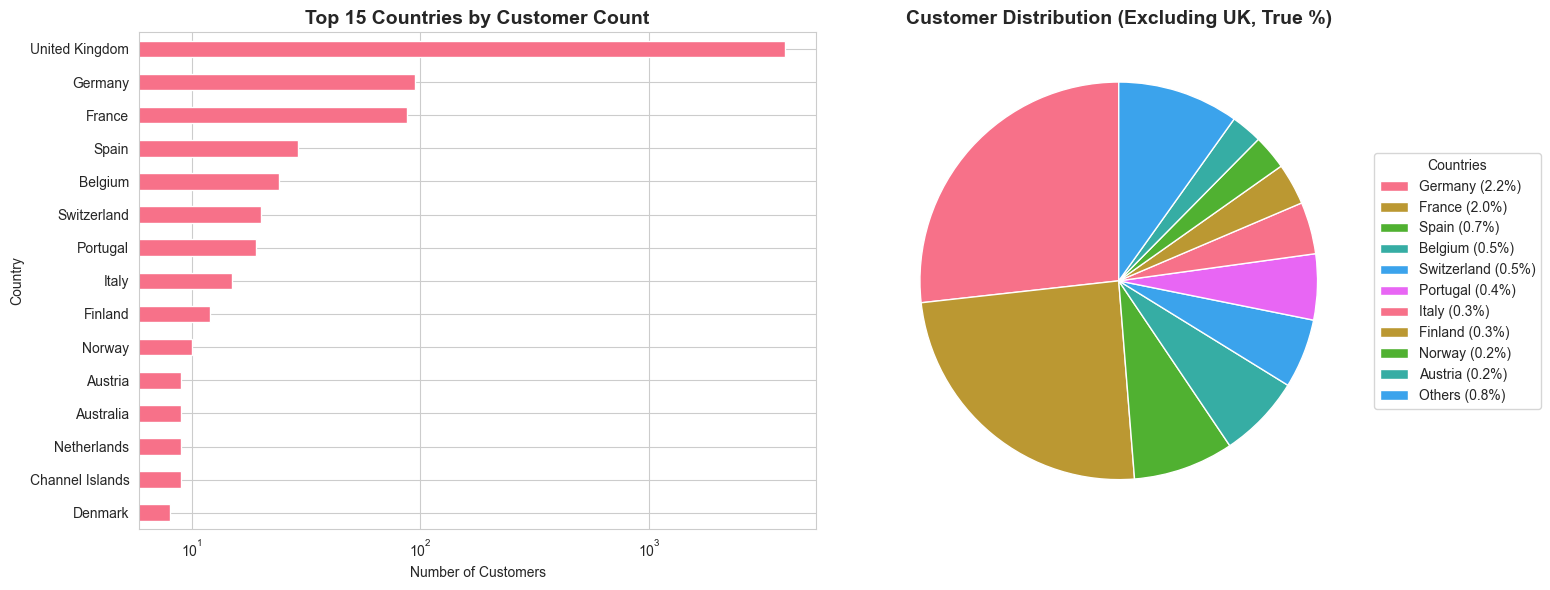

In [5]:
print("="*60)
print("GEOGRAPHIC CUSTOMER DISTRIBUTION")
print("="*60)

# Customer count by country
country_dist = customers['country'].value_counts().head(15)

print("\n Top 15 Countries by Customer Count:")
for i, (country, count) in enumerate(country_dist.items(), 1):
    pct = count / len(customers) * 100
    print(f"   {i:2d}. {country:20s}: {count:4,} customers ({pct:5.1f}%)")

# ================= VISUALISATION =================
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------- BAR CHART -----------
country_dist.plot(kind='barh', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('Country')
axes[0].set_title('Top 15 Countries by Customer Count', fontweight='bold', fontsize=14)
axes[0].invert_yaxis()

# ----------- PIE CHART (FIXED) -----------

# Total customers (IMPORTANT)
total_customers = len(customers)

# Remove UK
country_dist_no_uk = country_dist.drop('United Kingdom', errors='ignore')

# Top 10 (excluding UK) + Others
top10_countries = country_dist_no_uk.head(10)
others = country_dist_no_uk.iloc[10:].sum()
pie_data = pd.concat([top10_countries, pd.Series({'Others': others})])

# TRUE percentages (relative to full dataset)
true_percentages = pie_data / total_customers * 100

# Plot pie (no labels yet)
wedges, _ = axes[1].pie(
    pie_data,
    startangle=90
)

# Custom legend with REAL percentages
labels = [
    f"{country} ({true_percentages[country]:.1f}%)"
    for country in pie_data.index
]

axes[1].legend(
    wedges,
    labels,
    title="Countries",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

axes[1].set_title('Customer Distribution (Excluding UK, True %)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('customer_geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.2 Purchase Frequency Distribution

PURCHASE FREQUENCY ANALYSIS

 Purchase Frequency Statistics:
   • Mean: 5.1 orders
   • Median: 3 orders
   • Min: 1 orders
   • Max: 248 orders
   • Std Dev: 9.3

 Customer Frequency Segments:
   • One-time (1)        : 1,312 customers ( 30.0%)
   • Occasional (2-3)    : 1,303 customers ( 29.8%)
   • Regular (4-10)      : 1,293 customers ( 29.6%)
   • Frequent (10+)      :  459 customers ( 10.5%)


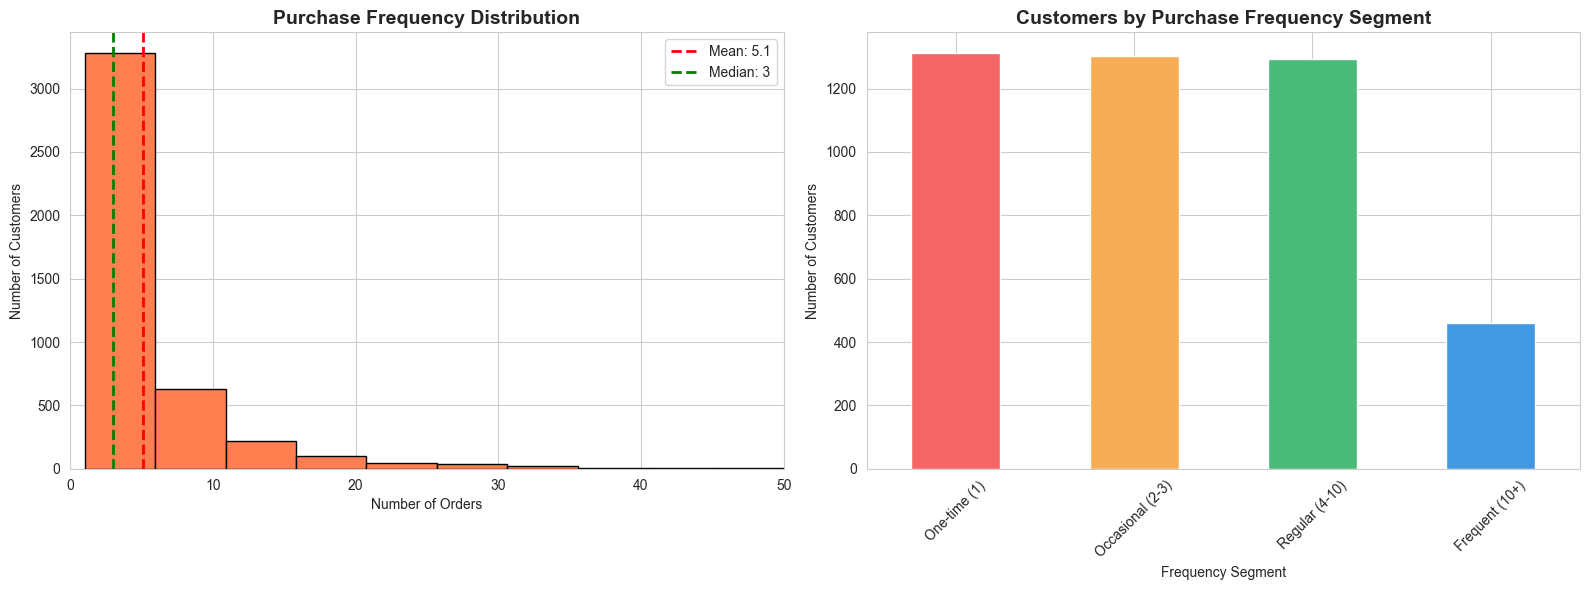

In [6]:
print("="*60)
print("PURCHASE FREQUENCY ANALYSIS")
print("="*60)

# Analyze total_orders from customers table
freq_stats = customers['total_orders'].describe()

print("\n Purchase Frequency Statistics:")
print(f"   • Mean: {freq_stats['mean']:.1f} orders")
print(f"   • Median: {freq_stats['50%']:.0f} orders")
print(f"   • Min: {freq_stats['min']:.0f} orders")
print(f"   • Max: {freq_stats['max']:.0f} orders")
print(f"   • Std Dev: {freq_stats['std']:.1f}")

# Categorize customers by frequency
customers['frequency_segment'] = pd.cut(customers['total_orders'], 
                                         bins=[0, 1, 3, 10, float('inf')],
                                         labels=['One-time (1)', 'Occasional (2-3)', 
                                                'Regular (4-10)', 'Frequent (10+)'])

freq_segments = customers['frequency_segment'].value_counts().sort_index()
print("\n Customer Frequency Segments:")
for segment, count in freq_segments.items():
    pct = count / len(customers) * 100
    print(f"   • {segment:20s}: {count:4,} customers ({pct:5.1f}%)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(customers['total_orders'], bins=50, color='coral', edgecolor='black')
axes[0].axvline(freq_stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {freq_stats["mean"]:.1f}')
axes[0].axvline(freq_stats['50%'], color='green', linestyle='--', linewidth=2, label=f'Median: {freq_stats["50%"]:.0f}')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Purchase Frequency Distribution', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].set_xlim(0, 50)  # Limit x-axis for readability

# Segment bar chart
freq_segments.plot(kind='bar', ax=axes[1], color=['#f56565', '#f6ad55', '#48bb78', '#4299e1'])
axes[1].set_xlabel('Frequency Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customers by Purchase Frequency Segment', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('purchase_frequency_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Customer Value Distribution (RFM Analysis)

CUSTOMER VALUE DISTRIBUTION (RFM)

 Customer Lifetime Value Statistics:
   • Mean: $1,925.99
   • Median: $658.26
   • Min: $0.00
   • Max: $279,489.02
   • Total Revenue: $8,310,627.88

 Customer Value Segments:
               customer_count  total_revenue  avg_revenue  revenue_pct
value_segment                                                         
Low Value                1079     189807.940   175.910973     2.283918
Medium Value             1079     492079.262   456.051216     5.921084
High Value               1078    1131422.511  1049.557060    13.614164
VIP                      1079    6497318.171  6021.610909    78.180834


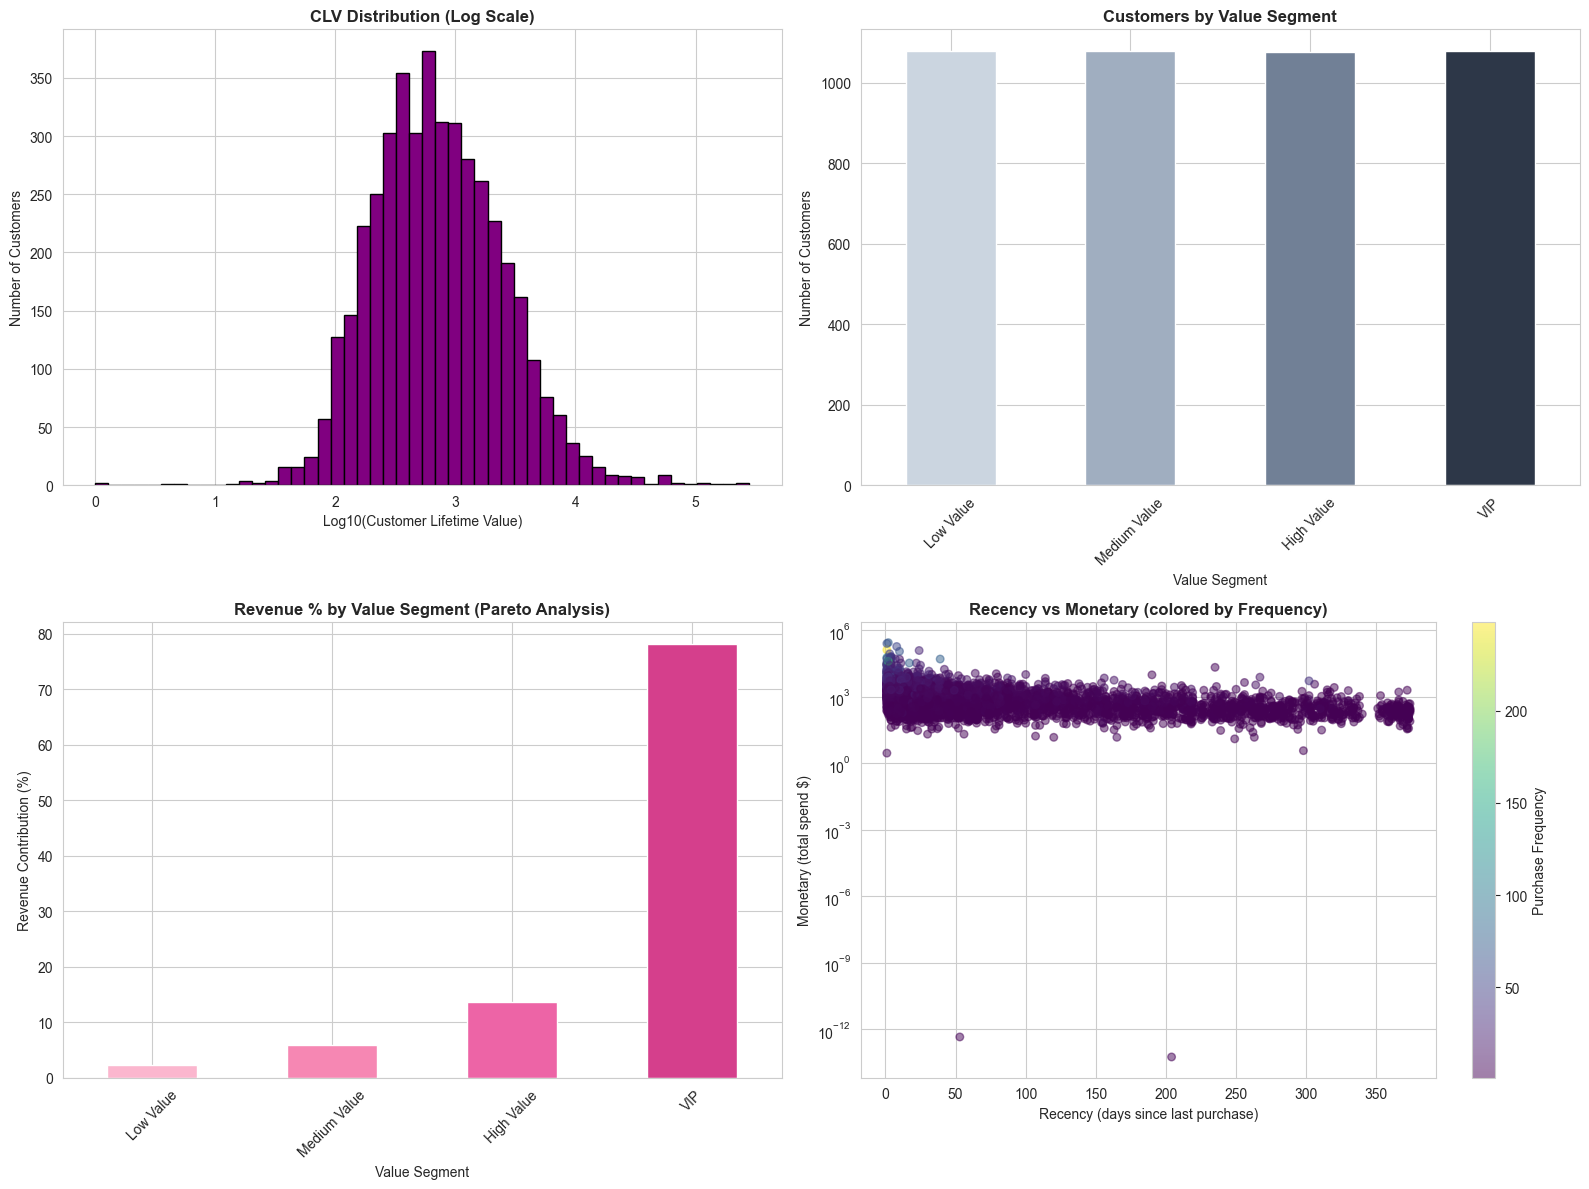


 Pareto Principle Check:
   • Top 20% of customers generate 73.5% of revenue


In [7]:
print("="*60)
print("CUSTOMER VALUE DISTRIBUTION (RFM)")
print("="*60)

# Check if RFM features exist
if all(col in customer_features.columns for col in ['recency', 'frequency', 'monetary']):
    
    # Monetary value statistics
    monetary_stats = customer_features['monetary'].describe()
    
    print("\n Customer Lifetime Value Statistics:")
    print(f"   • Mean: ${monetary_stats['mean']:,.2f}")
    print(f"   • Median: ${monetary_stats['50%']:,.2f}")
    print(f"   • Min: ${monetary_stats['min']:,.2f}")
    print(f"   • Max: ${monetary_stats['max']:,.2f}")
    print(f"   • Total Revenue: ${customer_features['monetary'].sum():,.2f}")
    
    # Categorize by value
    customer_features['value_segment'] = pd.qcut(customer_features['monetary'], 
                                                   q=4, 
                                                   labels=['Low Value', 'Medium Value', 
                                                          'High Value', 'VIP'])
    
    value_segments = customer_features.groupby('value_segment').agg({
        'customer_id': 'count',
        'monetary': ['sum', 'mean']
    })
    value_segments.columns = ['customer_count', 'total_revenue', 'avg_revenue']
    value_segments['revenue_pct'] = value_segments['total_revenue'] / value_segments['total_revenue'].sum() * 100
    
    print("\n Customer Value Segments:")
    print(value_segments.to_string())
    
    # Visualise
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Monetary distribution (log scale)
    axes[0, 0].hist(np.log10(customer_features['monetary'] + 1), bins=50, color='purple', edgecolor='black')
    axes[0, 0].set_xlabel('Log10(Customer Lifetime Value)')
    axes[0, 0].set_ylabel('Number of Customers')
    axes[0, 0].set_title('CLV Distribution (Log Scale)', fontweight='bold')
    
    # Value segments
    value_segments['customer_count'].plot(kind='bar', ax=axes[0, 1], color=['#cbd5e0', '#a0aec0', '#718096', '#2d3748'])
    axes[0, 1].set_xlabel('Value Segment')
    axes[0, 1].set_ylabel('Number of Customers')
    axes[0, 1].set_title('Customers by Value Segment', fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Revenue contribution
    value_segments['revenue_pct'].plot(kind='bar', ax=axes[1, 0], color=['#fbb6ce', '#f687b3', '#ed64a6', '#d53f8c'])
    axes[1, 0].set_xlabel('Value Segment')
    axes[1, 0].set_ylabel('Revenue Contribution (%)')
    axes[1, 0].set_title('Revenue % by Value Segment (Pareto Analysis)', fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Recency vs Monetary scatter
    axes[1, 1].scatter(customer_features['recency'], customer_features['monetary'], 
                       alpha=0.5, c=customer_features['frequency'], cmap='viridis', s=30)
    axes[1, 1].set_xlabel('Recency (days since last purchase)')
    axes[1, 1].set_ylabel('Monetary (total spend $)')
    axes[1, 1].set_title('Recency vs Monetary (colored by Frequency)', fontweight='bold')
    axes[1, 1].set_yscale('log')
    cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
    cbar.set_label('Purchase Frequency')
    
    plt.tight_layout()
    plt.savefig('customer_value_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Pareto principle check (80/20 rule)
    sorted_customers = customer_features.sort_values('monetary', ascending=False)
    sorted_customers['cumulative_revenue_pct'] = sorted_customers['monetary'].cumsum() / sorted_customers['monetary'].sum() * 100
    top_20_pct_customers = int(len(sorted_customers) * 0.2)
    revenue_from_top_20 = sorted_customers.iloc[:top_20_pct_customers]['cumulative_revenue_pct'].iloc[-1]
    
    print(f"\n Pareto Principle Check:")
    print(f"   • Top 20% of customers generate {revenue_from_top_20:.1f}% of revenue")
    
else:
    print("\n RFM features not found in customer_features")

## 1.4 Customer Cohort Analysis

CUSTOMER COHORT ANALYSIS

 Customer Acquisition by Month:
cohort_month
2010-12    948
2011-01    421
2011-02    380
2011-03    440
2011-04    298
2011-05    278
2011-06    235
2011-07    189
2011-08    167
2011-09    298
Freq: M


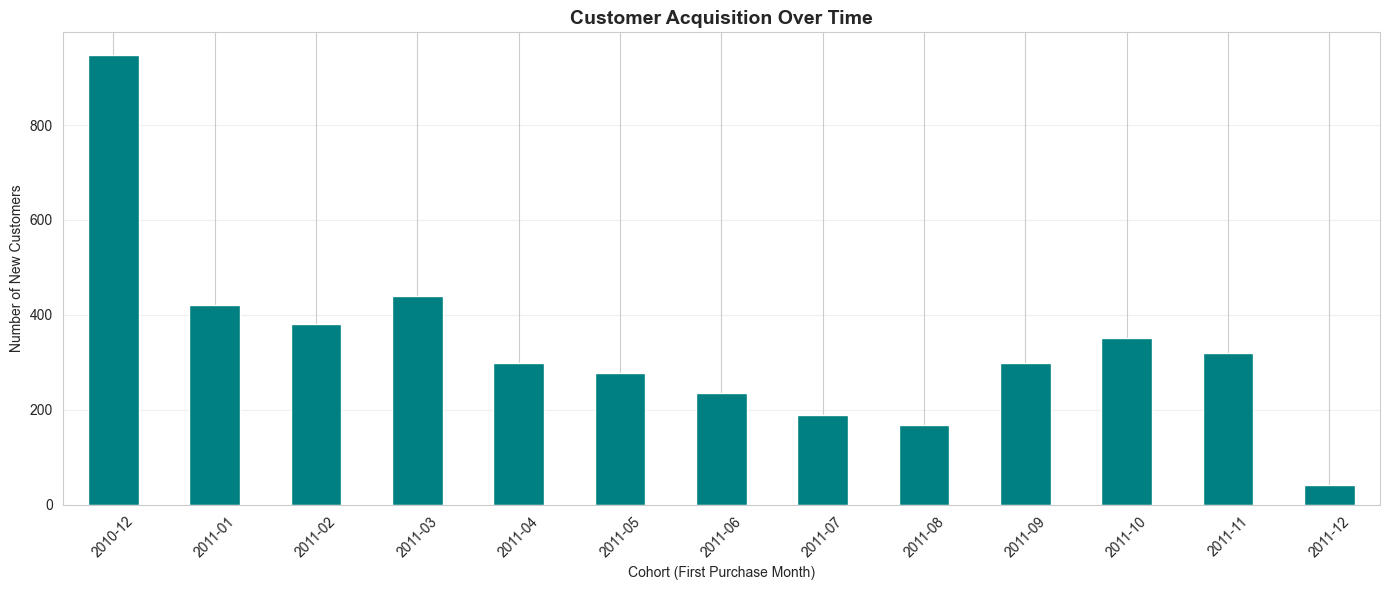


💡 Peak acquisition month: 2010-12 with 948 new customers


In [8]:
print("="*60)
print("CUSTOMER COHORT ANALYSIS")
print("="*60)

# Create cohort based on first purchase month
customers['cohort_month'] = customers['first_purchase_date'].dt.to_period('M')

cohort_counts = customers['cohort_month'].value_counts().sort_index()

print("\n Customer Acquisition by Month:")
print(cohort_counts.head(10).to_string())

# Visualise cohort acquisition
plt.figure(figsize=(14, 6))
cohort_counts.plot(kind='bar', color='teal')
plt.xlabel('Cohort (First Purchase Month)')
plt.ylabel('Number of New Customers')
plt.title('Customer Acquisition Over Time', fontweight='bold', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('customer_cohort_acquisition.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💡 Peak acquisition month: {cohort_counts.idxmax()} with {cohort_counts.max()} new customers")

## Step 1 Summary

In [9]:
print("\n" + "="*60)
print(" STEP 1 COMPLETE: CUSTOMER ANALYSIS")
print("="*60)
print("""
What We Analysed:
   ✓ Geographic distribution (top countries)
   ✓ Purchase frequency patterns (one-time vs. frequent)
   ✓ Customer value segments (Low/Medium/High/VIP)
   ✓ Pareto principle (80/20 rule)
   ✓ Customer cohorts (acquisition over time)

Deliverables:
   • customer_geographic_distribution.png
   • purchase_frequency_distribution.png
   • customer_value_analysis.png
   • customer_cohort_acquisition.png

Next STEP 2: Revenue & Sales Trends Analysis
""")


 STEP 1 COMPLETE: CUSTOMER ANALYSIS

What We Analysed:
   ✓ Geographic distribution (top countries)
   ✓ Purchase frequency patterns (one-time vs. frequent)
   ✓ Customer value segments (Low/Medium/High/VIP)
   ✓ Pareto principle (80/20 rule)
   ✓ Customer cohorts (acquisition over time)

Deliverables:
   • customer_geographic_distribution.png
   • purchase_frequency_distribution.png
   • customer_value_analysis.png
   • customer_cohort_acquisition.png

Next STEP 2: Revenue & Sales Trends Analysis



---
<a id='Step-2'></a>
# Step 2: Revenue & Sales Trends Analysis

## Objectives:
- Analyze revenue trends over time
- Identify seasonal patterns
- Revenue by geography
- Day-of-week and time-of-Step patterns
- Growth analysis

## 2.1 Overall Revenue Trends

REVENUE TRENDS OVER TIME

 Revenue Summary:
   • Total Revenue: $8,297,398.74
   • Average Daily Revenue: $27,204.59
   • Average Weekly Revenue: $156,554.69
   • Average Monthly Revenue: $638,261.44
   • Highest Daily Revenue: $103,385.26 on 2011-09-20


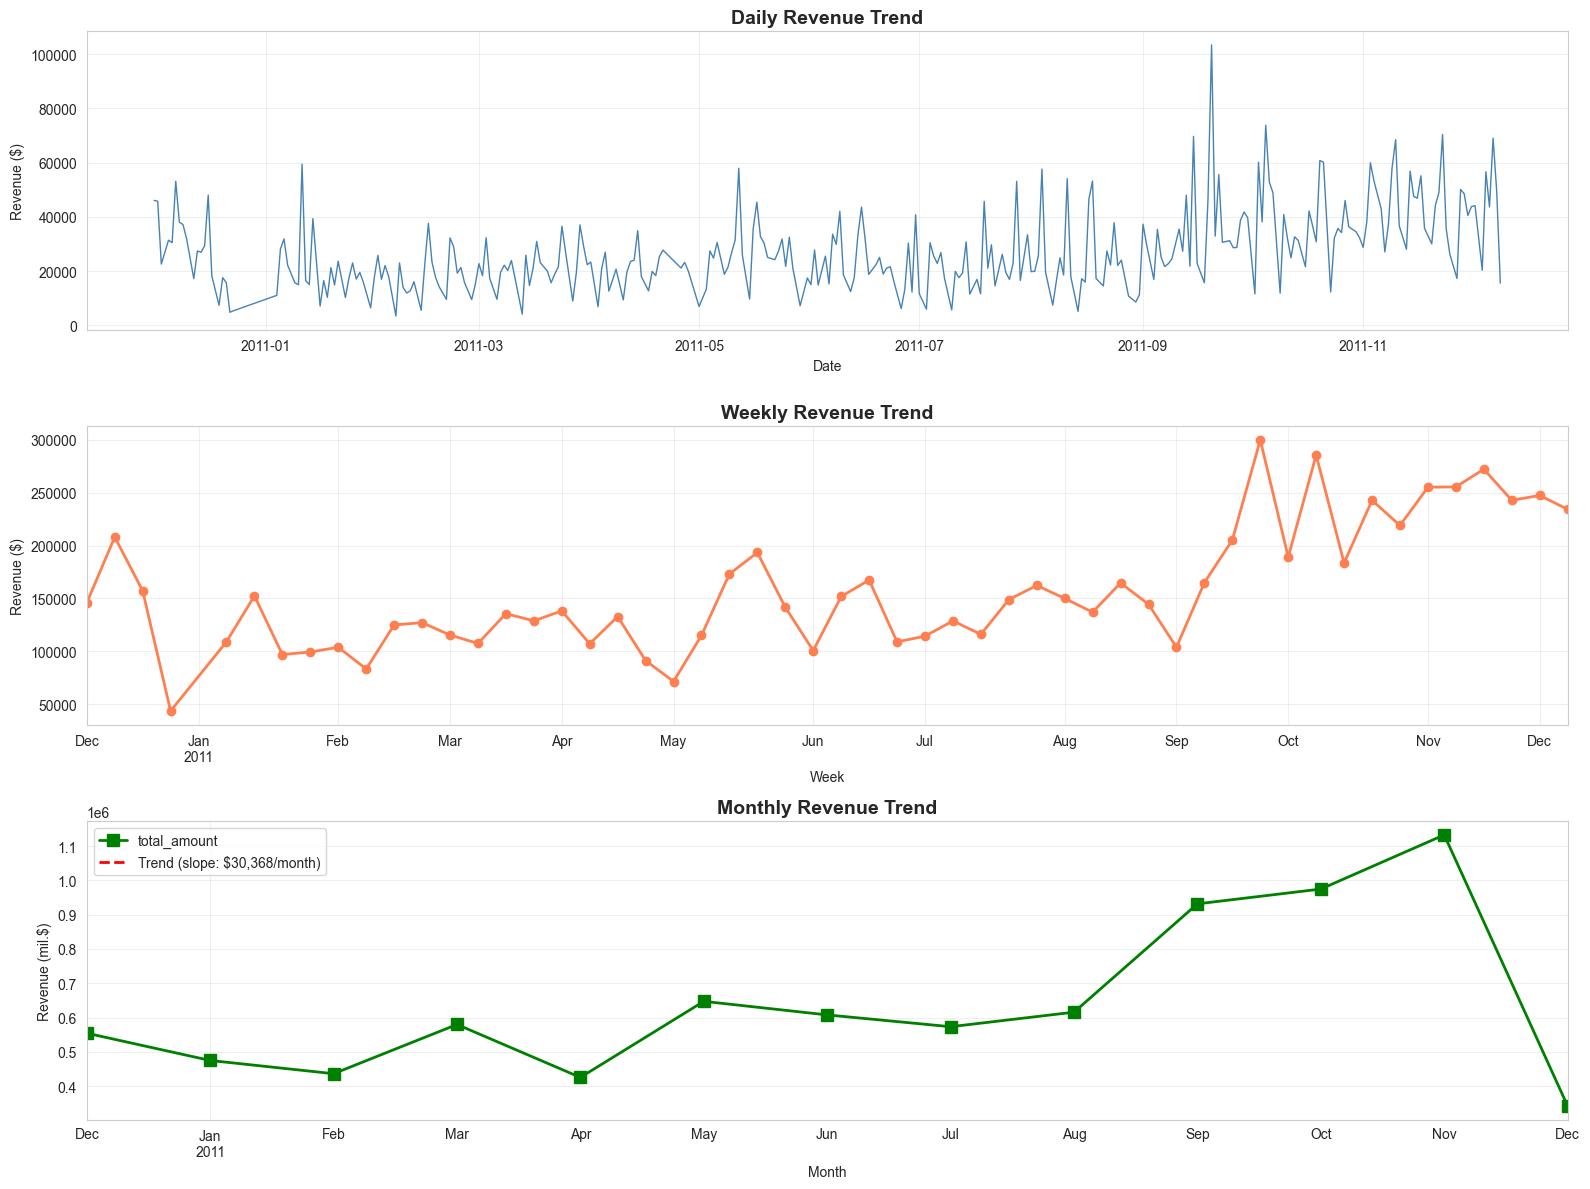


 Revenue Growth:
   • First month: $554,604.02
   • Last month: $342,506.38
   • Overall growth: -38.2%


In [10]:
print("="*60)
print("REVENUE TRENDS OVER TIME")
print("="*60)

# Daily revenue
daily_revenue = invoices.groupby(invoices['invoice_date'].dt.date)['total_amount'].sum()

# Weekly revenue
invoices['week'] = invoices['invoice_date'].dt.to_period('W')
weekly_revenue = invoices.groupby('week')['total_amount'].sum()

# Monthly revenue
invoices['month'] = invoices['invoice_date'].dt.to_period('M')
monthly_revenue = invoices.groupby('month')['total_amount'].sum()

print("\n Revenue Summary:")
print(f"   • Total Revenue: ${invoices['total_amount'].sum():,.2f}")
print(f"   • Average Daily Revenue: ${daily_revenue.mean():,.2f}")
print(f"   • Average Weekly Revenue: ${weekly_revenue.mean():,.2f}")
print(f"   • Average Monthly Revenue: ${monthly_revenue.mean():,.2f}")
print(f"   • Highest Daily Revenue: ${daily_revenue.max():,.2f} on {daily_revenue.idxmax()}")

# Visualise
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Daily revenue
daily_revenue.plot(ax=axes[0], color='steelblue', linewidth=1)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Daily Revenue Trend', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3)

# Weekly revenue
weekly_revenue.plot(ax=axes[1], color='coral', linewidth=2, marker='o')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_title('Weekly Revenue Trend', fontweight='bold', fontsize=14)
axes[1].grid(alpha=0.3)

# Monthly revenue with trend line
monthly_revenue.plot(ax=axes[2], color='green', linewidth=2, marker='s', markersize=8)
# Add trend line
x = np.arange(len(monthly_revenue))
y = monthly_revenue.values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
axes[2].plot(monthly_revenue.index.to_timestamp(), p(x), "r--", linewidth=2, label=f'Trend (slope: ${z[0]:,.0f}/month)')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Revenue (mil.$)')
axes[2].set_title('Monthly Revenue Trend', fontweight='bold', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# Growth calculation
first_month_revenue = monthly_revenue.iloc[0]
last_month_revenue = monthly_revenue.iloc[-1]
revenue_growth = (last_month_revenue - first_month_revenue) / first_month_revenue * 100

print(f"\n Revenue Growth:")
print(f"   • First month: ${first_month_revenue:,.2f}")
print(f"   • Last month: ${last_month_revenue:,.2f}")
print(f"   • Overall growth: {revenue_growth:+.1f}%")

## 2.2 Seasonal Patterns

SEASONAL PATTERN ANALYSIS

 Seasonal Patterns:

Best day: Tuesday ($1,562,340.91)
Worst day: Sunday ($784,418.85)

Best month: November ($1,132,407.74)
Best hour: 12:00 ($1,337,064.42)


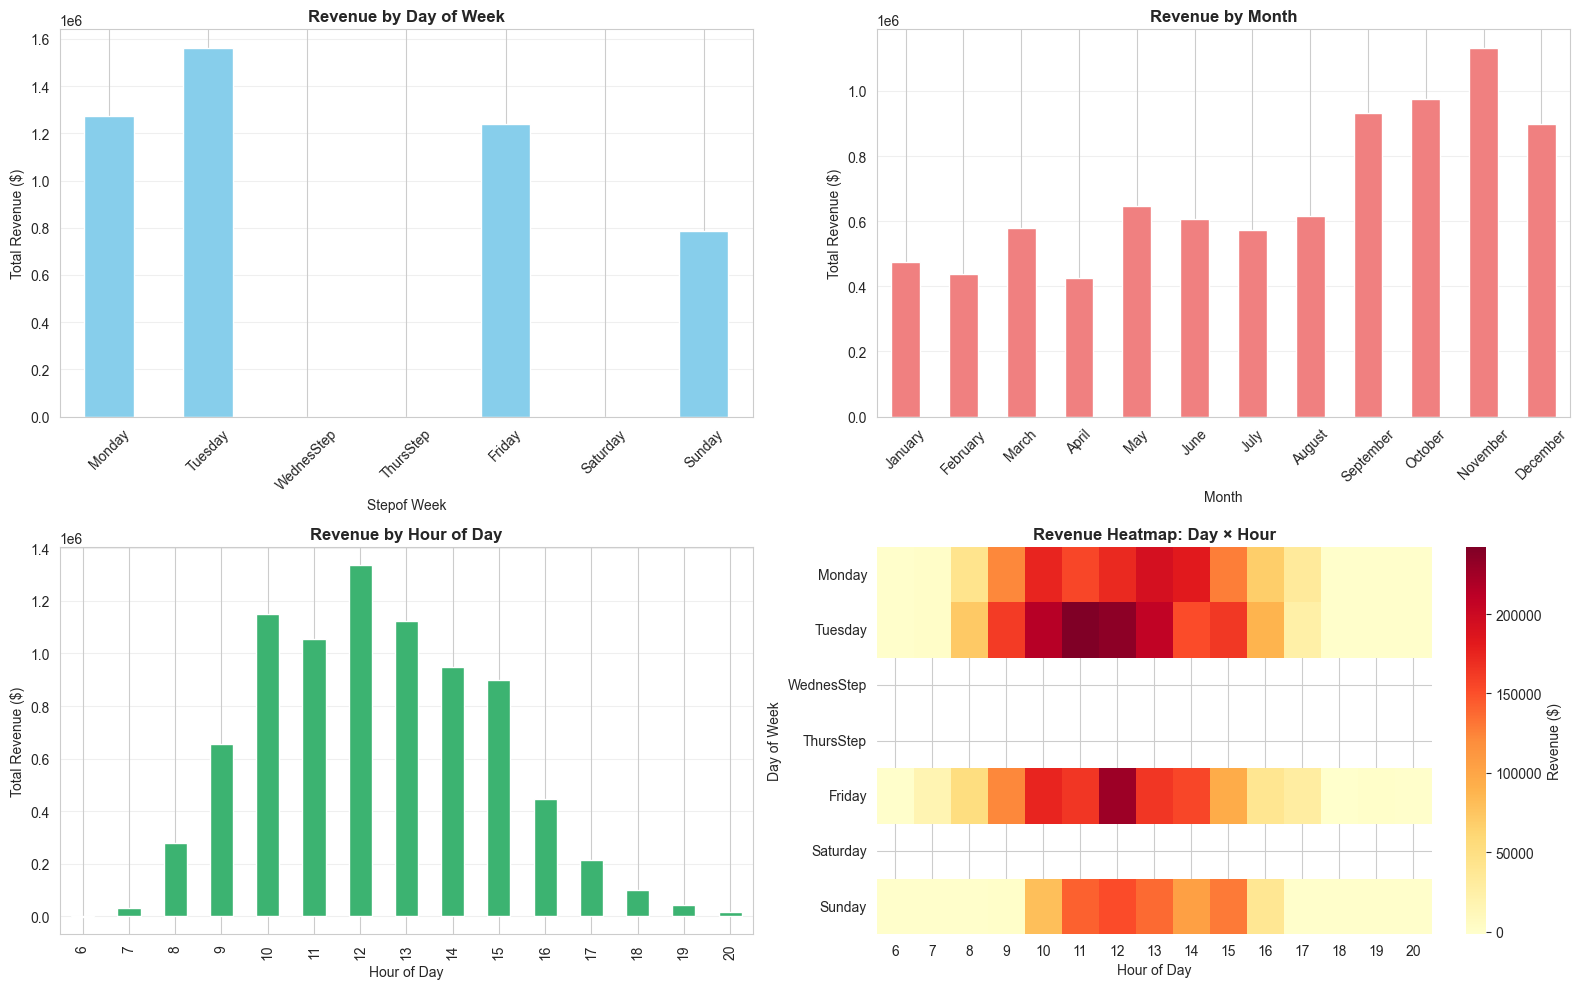

In [11]:
print("="*60)
print("SEASONAL PATTERN ANALYSIS")
print("="*60)

# Extract time components
invoices['day_of_week'] = invoices['invoice_date'].dt.day_name()
invoices['hour'] = invoices['invoice_date'].dt.hour
invoices['month_name'] = invoices['invoice_date'].dt.month_name()

# Revenue by Step of week
day_order = ['Monday', 'Tuesday', 'WednesStep', 'ThursStep', 'Friday', 'Saturday', 'Sunday']
dow_revenue = invoices.groupby('day_of_week')['total_amount'].sum().reindex(day_order)

# Revenue by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_revenue = invoices.groupby('month_name')['total_amount'].sum().reindex([m for m in month_order if m in invoices['month_name'].unique()])

# Revenue by hour
hour_revenue = invoices.groupby('hour')['total_amount'].sum()

print("\n Seasonal Patterns:")
print(f"\nBest day: {dow_revenue.idxmax()} (${dow_revenue.max():,.2f})")
print(f"Worst day: {dow_revenue.idxmin()} (${dow_revenue.min():,.2f})")
print(f"\nBest month: {month_revenue.idxmax()} (${month_revenue.max():,.2f})")
print(f"Best hour: {hour_revenue.idxmax()}:00 (${hour_revenue.max():,.2f})")

# Visualise
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Stepof week
dow_revenue.plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_xlabel('Stepof Week')
axes[0, 0].set_ylabel('Total Revenue ($)')
axes[0, 0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Month
month_revenue.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Total Revenue ($)')
axes[0, 1].set_title('Revenue by Month', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Hour of day
hour_revenue.plot(kind='bar', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Total Revenue ($)')
axes[1, 0].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Heatmap: Day of week vs Hour
pivot_data = invoices.groupby(['day_of_week', 'hour'])['total_amount'].sum().unstack(fill_value=0)
pivot_data = pivot_data.reindex(day_order)
sns.heatmap(pivot_data, ax=axes[1, 1], cmap='YlOrRd', fmt='.0f', cbar_kws={'label': 'Revenue ($)'})
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Day of Week')
axes[1, 1].set_title('Revenue Heatmap: Day × Hour', fontweight='bold')

plt.tight_layout()
plt.savefig('seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.3 Revenue by Geography

REVENUE BY GEOGRAPHY

 Top 15 Countries by Revenue:
                     revenue  order_count  avg_order_value
country                                                   
United Kingdom   6767873.394        19854       340.882109
Netherlands       284661.540          100      2846.615400
EIRE              250285.220          319       784.593166
Germany           221698.210          603       367.658723
France            196712.840          458       429.504017
Australia         137077.270           69      1986.627101
Switzerland        55739.400           71       785.061972
Spain              54774.580          105       521.662667
Belgium            40910.960          119       343.789580
Sweden             36595.910           46       795.563261
Japan              35340.620           28      1262.165000
Norway             35163.460           40       879.086500
Portugal           29059.810           70       415.140143
Finland            22326.740           48       465.140417
Chan

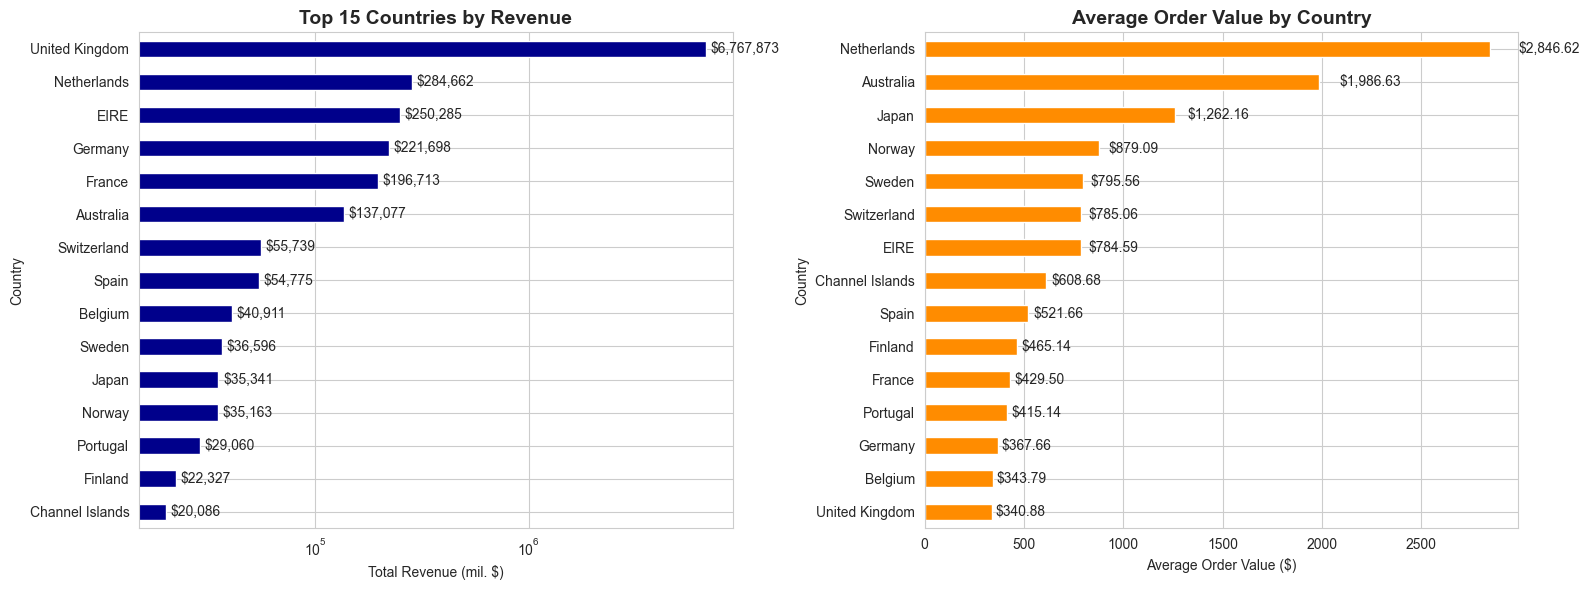


 Highest revenue: United Kingdom ($6,767,873.39)
 Highest AOV: Netherlands ($2,846.62)


In [12]:
print("="*60)
print("REVENUE BY GEOGRAPHY")
print("="*60)

# Revenue by country
country_revenue = invoices.groupby('country').agg({
    'total_amount': 'sum',
    'invoice_no': 'count'
}).rename(columns={'total_amount': 'revenue', 'invoice_no': 'order_count'})
country_revenue['avg_order_value'] = country_revenue['revenue'] / country_revenue['order_count']
country_revenue = country_revenue.sort_values('revenue', ascending=False).head(15)

print("\n Top 15 Countries by Revenue:")
print(country_revenue.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by country
revenue_series = country_revenue['revenue']
revenue_series.plot(kind='barh', ax=axes[0], color='darkblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Total Revenue (mil. $)')
axes[0].set_ylabel('Country')
axes[0].set_title('Top 15 Countries by Revenue', fontweight='bold', fontsize=14)
axes[0].invert_yaxis()

# Annotate revenue values
for i, v in enumerate(revenue_series):
    axes[0].text(v * 1.05, i, f"${v:,.0f}", va='center')

# Plot 2: Average order value by country, sorted descending
aov_series = country_revenue['avg_order_value'].sort_values(ascending=False)

aov_series.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Average Order Value ($)')
axes[1].set_ylabel('Country')
axes[1].set_title('Average Order Value by Country', fontweight='bold', fontsize=14)
axes[1].invert_yaxis()  # keep the highest value on top

# Annotate AOV values
for i, v in enumerate(aov_series):
    axes[1].text(v * 1.05, i, f"${v:,.2f}", va='center')

plt.tight_layout()
plt.savefig('revenue_by_geography.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Highest revenue: {country_revenue['revenue'].idxmax()} (${country_revenue['revenue'].max():,.2f})")
print(f" Highest AOV: {country_revenue['avg_order_value'].idxmax()} (${country_revenue['avg_order_value'].max():,.2f})")

## Step 2 Summary

In [13]:
print("\n" + "="*60)
print(" STEP 2 COMPLETE: REVENUE & SALES TRENDS")
print("="*60)
print("""
What We Analysed:
   ✓ Daily, weekly, monthly revenue trends
   ✓ Revenue growth rate
   ✓ Seasonal patterns (day, month, hour)
   ✓ Revenue by geography
   ✓ Peak sales periods identified

Deliverables:
   • revenue_trends.png
   • seasonal_patterns.png
   • revenue_by_geography.png

STEP 3: Product Performance Analysis
""")


 STEP 2 COMPLETE: REVENUE & SALES TRENDS

What We Analysed:
   ✓ Daily, weekly, monthly revenue trends
   ✓ Revenue growth rate
   ✓ Seasonal patterns (day, month, hour)
   ✓ Revenue by geography
   ✓ Peak sales periods identified

Deliverables:
   • revenue_trends.png
   • seasonal_patterns.png
   • revenue_by_geography.png

STEP 3: Product Performance Analysis



---
<a id='Step-3'></a>
# Step 3: Product Performance Analysis

## Objectives:
- Identify top-selling products
- Analyse product categories (if available)
- Price vs. sales volume relationship
- Product diversity metrics
- Slow-moving vs. fast-moving inventory

## 3.1 Top Performing Products

TOP PERFORMING PRODUCTS

 Top 10 Products by Quantity Sold:
                             description  total_quantity  total_revenue
2812   WORLD WAR 2 GLIDERS ASSTD DESIGNS           53215       13332.33
1092                SMALL POPCORN HOLDER           48712       36859.88
3235             JUMBO BAG RED RETROSPOT           45066       83236.76
3069       ASSORTED COLOUR BIRD ORNAMENT           35292       56462.04
3249  WHITE HANGING HEART T-LIGHT HOLDER           34204       93979.20
425      PACK OF 72 RETROSPOT CAKE CASES           33385       16234.75
1923                  RABBIT NIGHT LIGHT           27094       51137.80
1356             MINI PAINT SET VINTAGE            25880       15911.84
1473          PACK OF 12 LONDON TISSUES            25321        7258.55
914   PACK OF 60 PINK PAISLEY CAKE CASES           24139       11560.95

 Top 10 Products by Revenue:
                             description  total_revenue  total_quantity
1292            REGENCY CAKESTAND 3 TIER      

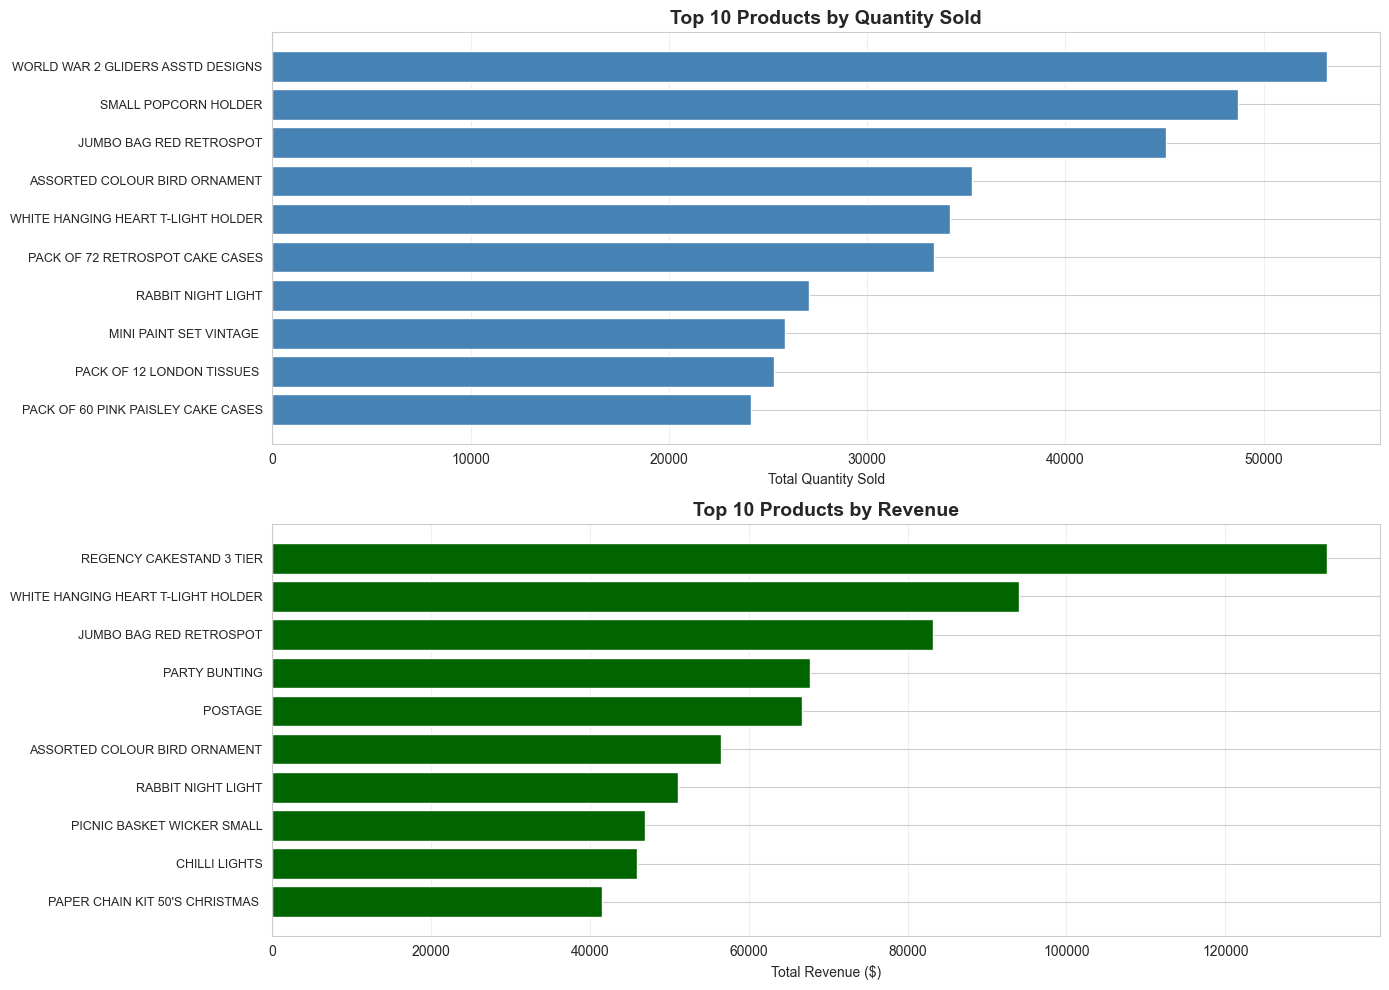

In [14]:
print("="*60)
print("TOP PERFORMING PRODUCTS")
print("="*60)

# Product sales analysis
product_sales = invoice_items.groupby('stock_code').agg({
    'quantity': 'sum',
    'line_total': 'sum',
    'invoice_no': 'nunique'
}).rename(columns={'quantity': 'total_quantity', 
                   'line_total': 'total_revenue',
                   'invoice_no': 'num_orders'})

# Merge with product info
product_sales = product_sales.merge(products[['stock_code', 'description', 'avg_unit_price']], 
                                     on='stock_code', how='left')

# Top by quantity
top_by_quantity = product_sales.nlargest(20, 'total_quantity')

# Top by revenue
top_by_revenue = product_sales.nlargest(20, 'total_revenue')

print("\n Top 10 Products by Quantity Sold:")
print(top_by_quantity[['description', 'total_quantity', 'total_revenue']].head(10).to_string())

print("\n Top 10 Products by Revenue:")
print(top_by_revenue[['description', 'total_revenue', 'total_quantity']].head(10).to_string())

# Visualise
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top by quantity
top_10_qty = top_by_quantity.head(10)
axes[0].barh(range(len(top_10_qty)), top_10_qty['total_quantity'], color='steelblue')
axes[0].set_yticks(range(len(top_10_qty)))
axes[0].set_yticklabels([desc[:40] + '...' if len(str(desc)) > 40 else desc 
                          for desc in top_10_qty['description']], fontsize=9)
axes[0].set_xlabel('Total Quantity Sold')
axes[0].set_title('Top 10 Products by Quantity Sold', fontweight='bold', fontsize=14)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top by revenue
top_10_rev = top_by_revenue.head(10)
axes[1].barh(range(len(top_10_rev)), top_10_rev['total_revenue'], color='darkgreen')
axes[1].set_yticks(range(len(top_10_rev)))
axes[1].set_yticklabels([desc[:40] + '...' if len(str(desc)) > 40 else desc 
                          for desc in top_10_rev['description']], fontsize=9)
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_title('Top 10 Products by Revenue', fontweight='bold', fontsize=14)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_products.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
print(products.columns)

Index(['stock_code', 'description', 'avg_unit_price', 'total_quantity_sold'], dtype='str')


## 3.2 Price vs. Sales Volume Analysis

PRICE VS. SALES VOLUME ANALYSIS

 Sales by Price Category:
                product_count  total_quantity  total_revenue  avg_price
price_category                                                         
Budget                    911         1895930     957022.113   0.529449
Economy                   910         1348566    1796492.000   1.287816
Mid-Range                 910         1202170    2818147.180   2.541803
Premium                   910          444143    2780889.161   9.125084


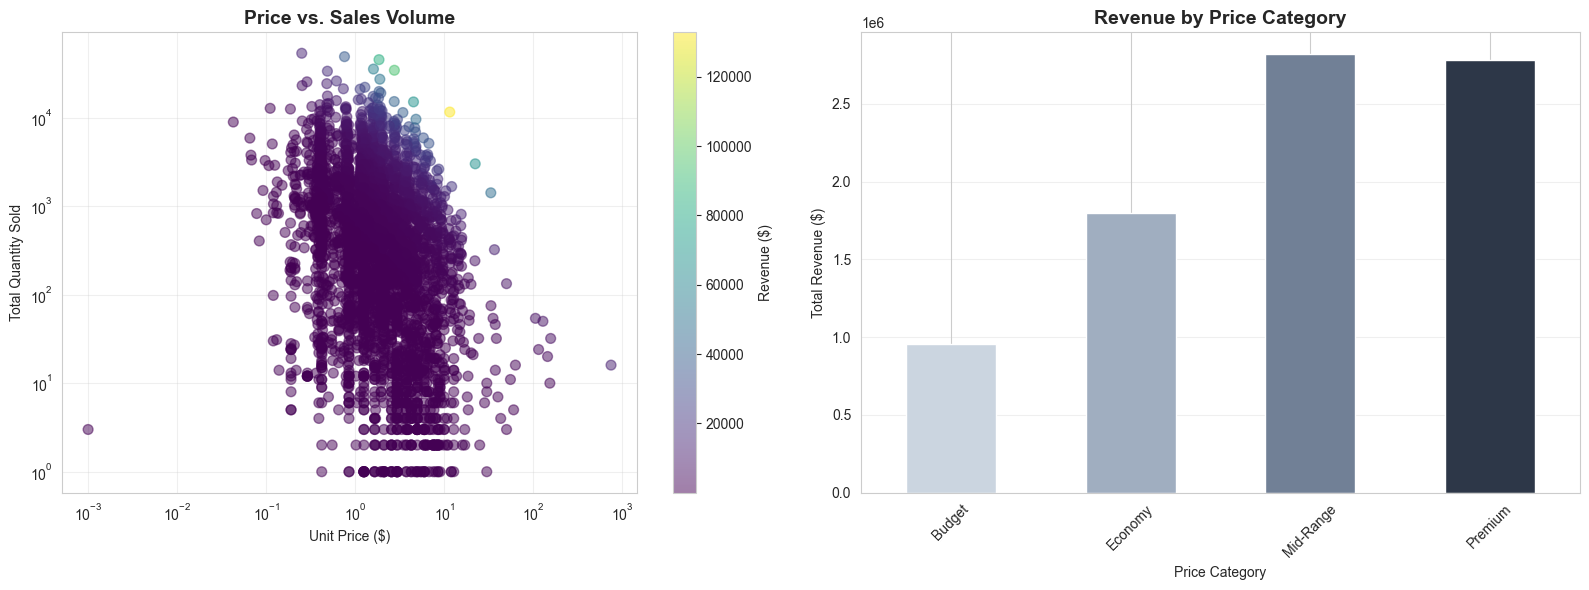


 Correlation (Price vs Quantity): -0.054
   → Weak correlation: Price has little impact on sales volume


In [16]:
print("="*60)
print("PRICE VS. SALES VOLUME ANALYSIS")
print("="*60)

product_sales['avg_price'] = product_sales['total_revenue'] / product_sales['total_quantity']

# Filter valid products (positive price and quantity)
valid_products = product_sales[(product_sales['avg_price'] > 0) & 
                                (product_sales['total_quantity'] > 0)]

# Categorize by price
valid_products['price_category'] = pd.qcut(valid_products['avg_price'], 
                                             q=4, 
                                             labels=['Budget', 'Economy', 'Mid-Range', 'Premium'],
                                             duplicates='drop')

# Analyze by price category
price_analysis = valid_products.groupby('price_category').agg({
    'stock_code': 'count',
    'total_quantity': 'sum',
    'total_revenue': 'sum',
    'avg_price': 'mean'
}).rename(columns={'stock_code': 'product_count'})

print("\n Sales by Price Category:")
print(price_analysis.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Price vs Quantity
axes[0].scatter(valid_products['avg_price'], valid_products['total_quantity'], 
                alpha=0.5, s=50, c=valid_products['total_revenue'], cmap='viridis')
axes[0].set_xlabel('Unit Price ($)')
axes[0].set_ylabel('Total Quantity Sold')
axes[0].set_title('Price vs. Sales Volume', fontweight='bold', fontsize=14)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)
cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar.set_label('Revenue ($)')

# Revenue by price category
price_analysis['total_revenue'].plot(kind='bar', ax=axes[1], color=['#cbd5e0', '#a0aec0', '#718096', '#2d3748'])
axes[1].set_xlabel('Price Category')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_title('Revenue by Price Category', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('price_vs_sales.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation
correlation = valid_products[['avg_price', 'total_quantity']].corr().iloc[0, 1]
print(f"\n Correlation (Price vs Quantity): {correlation:.3f}")
if correlation < -0.3:
    print("   → Negative correlation: Higher prices tend to have lower sales volume")
elif correlation > 0.3:
    print("   → Positive correlation: Higher prices tend to have higher sales volume")
else:
    print("   → Weak correlation: Price has little impact on sales volume")

## 3.3 Product Velocity & Inventory Analysis

PRODUCT VELOCITY ANALYSIS

 Product Velocity Analysis:
                   product_count  total_revenue  sales_per_day
velocity_category                                             
Slow-Moving                 1228     251413.084       0.055546
Medium-Moving               1228    1377548.440       0.250445
Fast-Moving                 1228    6668437.220       1.114856


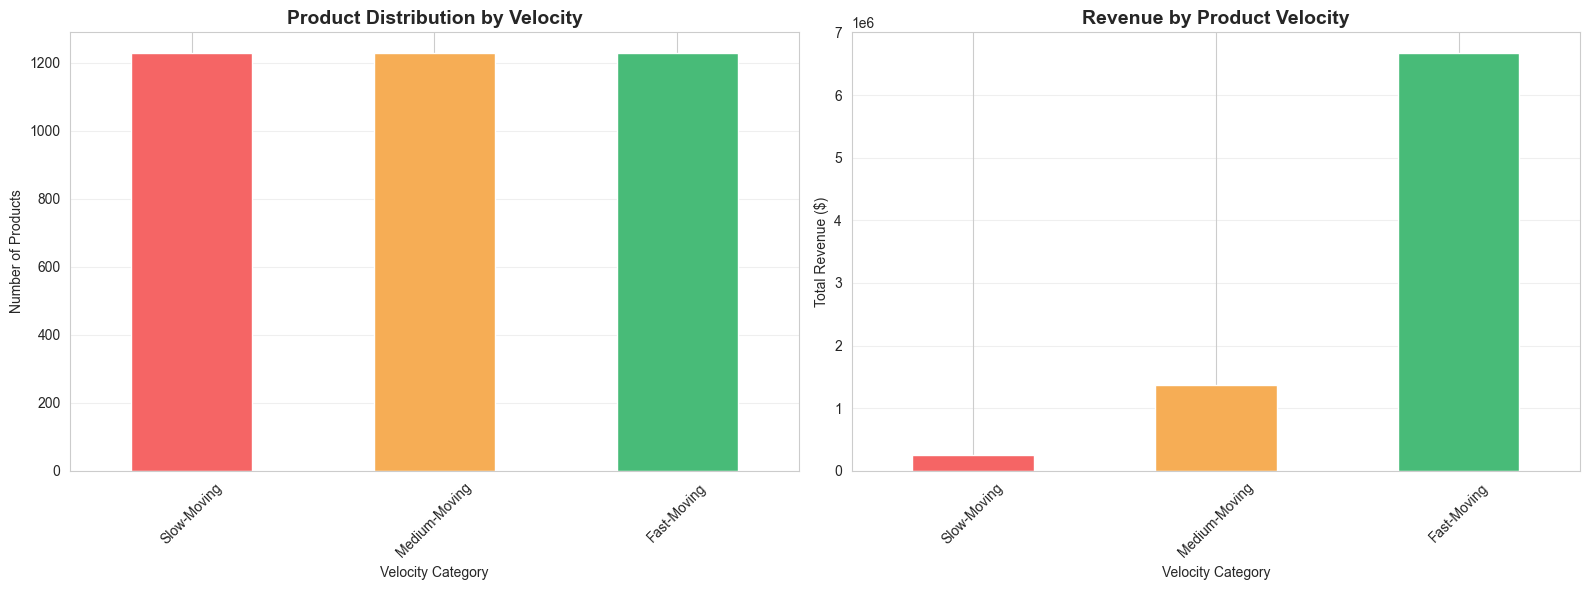


 Recommendation: Focus inventory investment on Fast-Moving products for better ROI


In [17]:
print("="*60)
print("PRODUCT VELOCITY ANALYSIS")
print("="*60)

# Calculate days products were active
product_dates = invoice_items.merge(invoices[['invoice_no', 'invoice_date']], on='invoice_no')
product_activity = product_dates.groupby('stock_code')['invoice_date'].agg(['min', 'max', 'count'])
product_activity['days_active'] = (product_activity['max'] - product_activity['min']).dt.days + 1
product_activity['sales_per_day'] = product_activity['count'] / product_activity['days_active']

# Merge with product sales
product_sales = product_sales.merge(product_activity[['sales_per_day']], 
                                     left_on='stock_code', right_index=True, how='left')

# Categorize by velocity
product_sales['velocity_category'] = pd.qcut(product_sales['sales_per_day'].fillna(0), 
                                               q=3, 
                                               labels=['Slow-Moving', 'Medium-Moving', 'Fast-Moving'],
                                               duplicates='drop')

velocity_summary = product_sales.groupby('velocity_category').agg({
    'stock_code': 'count',
    'total_revenue': 'sum',
    'sales_per_day': 'mean'
}).rename(columns={'stock_code': 'product_count'})

print("\n Product Velocity Analysis:")
print(velocity_summary.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Product count by velocity
velocity_summary['product_count'].plot(kind='bar', ax=axes[0], color=['#f56565', '#f6ad55', '#48bb78'])
axes[0].set_xlabel('Velocity Category')
axes[0].set_ylabel('Number of Products')
axes[0].set_title('Product Distribution by Velocity', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Revenue by velocity
velocity_summary['total_revenue'].plot(kind='bar', ax=axes[1], color=['#f56565', '#f6ad55', '#48bb78'])
axes[1].set_xlabel('Velocity Category')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_title('Revenue by Product Velocity', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('product_velocity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Recommendation: Focus inventory investment on Fast-Moving products for better ROI")

## Step 3 Summary

In [18]:
print("\n" + "="*60)
print(" STEP 3 COMPLETE: PRODUCT PERFORMANCE ANALYSIS")
print("="*60)
print("""
What We Analysed:
   ✓ Top 20 products by quantity and revenue
   ✓ Price vs. sales volume relationship
   ✓ Revenue by price category
   ✓ Product velocity (slow/medium/fast moving)
   ✓ Inventory optimisation insights

Deliverables:
   • top_products.png
   • price_vs_sales.png
   • product_velocity.png

STEP 4: Statistical Analysis & Correlations
""")


 STEP 3 COMPLETE: PRODUCT PERFORMANCE ANALYSIS

What We Analysed:
   ✓ Top 20 products by quantity and revenue
   ✓ Price vs. sales volume relationship
   ✓ Revenue by price category
   ✓ Product velocity (slow/medium/fast moving)
   ✓ Inventory optimisation insights

Deliverables:
   • top_products.png
   • price_vs_sales.png
   • product_velocity.png

STEP 4: Statistical Analysis & Correlations



---
<a id='Step-4'></a>
# Step 4: Statistical Analysis & Correlations

## Objectives:
- Correlation analysis between key metrics
- Statistical hypothesis testing
- Distribution analysis
- Basket analysis
- Key metric relationships

## 4.1 Correlation Analysis

CORRELATION ANALYSIS

 Correlation Matrix (Top Features):
            recency  frequency  monetary
recency    1.000000  -0.258647 -0.130667
frequency -0.258647   1.000000  0.565218
monetary  -0.130667   0.565218  1.000000


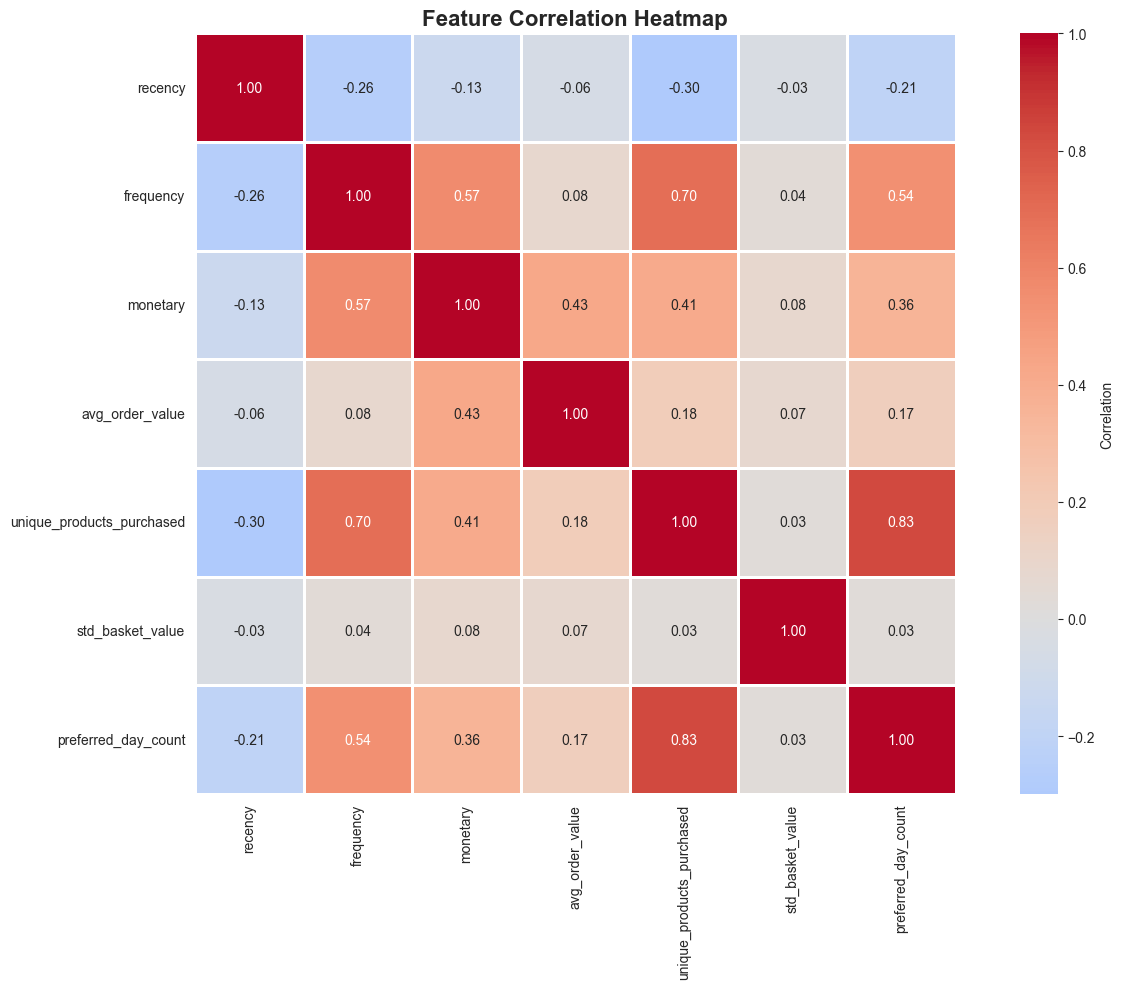


 Strong Correlations (|r| > 0.5):
   • unique_products_purchased <-> preferred_day_count: 0.830
   • frequency <-> unique_products_purchased: 0.695
   • frequency <-> monetary: 0.565
   • frequency <-> preferred_day_count: 0.539


In [19]:
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select key metrics for correlation
if all(col in customer_features.columns for col in ['recency', 'frequency', 'monetary']):
    
    # Select numeric columns
    numeric_cols = customer_features.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove customer_id if present
    if 'customer_id' in numeric_cols:
        numeric_cols.remove('customer_id')
    
    # Calculate correlation matrix
    correlation_matrix = customer_features[numeric_cols].corr()
    
    print("\n Correlation Matrix (Top Features):")
    key_features = ['recency', 'frequency', 'monetary']
    if all(f in correlation_matrix.columns for f in key_features):
        print(correlation_matrix.loc[key_features, key_features].to_string())
    
    # Visualise
    plt.figure(figsize=(14, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
    plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Find strong correlations
    strong_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                strong_corr.append((correlation_matrix.columns[i], 
                                   correlation_matrix.columns[j], 
                                   correlation_matrix.iloc[i, j]))
    
    if strong_corr:
        print("\n Strong Correlations (|r| > 0.5):")
        for feat1, feat2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True)[:10]:
            print(f"   • {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("\n RFM features not found")

## 4.2 Statistical Hypothesis Testing

STATISTICAL HYPOTHESIS TESTING

 Test 1: Repeat vs. One-Time Customer Spending
   H0: No difference in spending between groups
   H1: Repeat customers spend differently

   One-time customers (n=1,282): Avg spend $346.43
   Repeat customers (n=3,033): Avg spend $2,593.64

   T-statistic: 8.2201
   P-value: 0.000000
    Result: REJECT H0 (significant difference at α=0.05)
    Repeat customers spend $2,247.21 more on average!


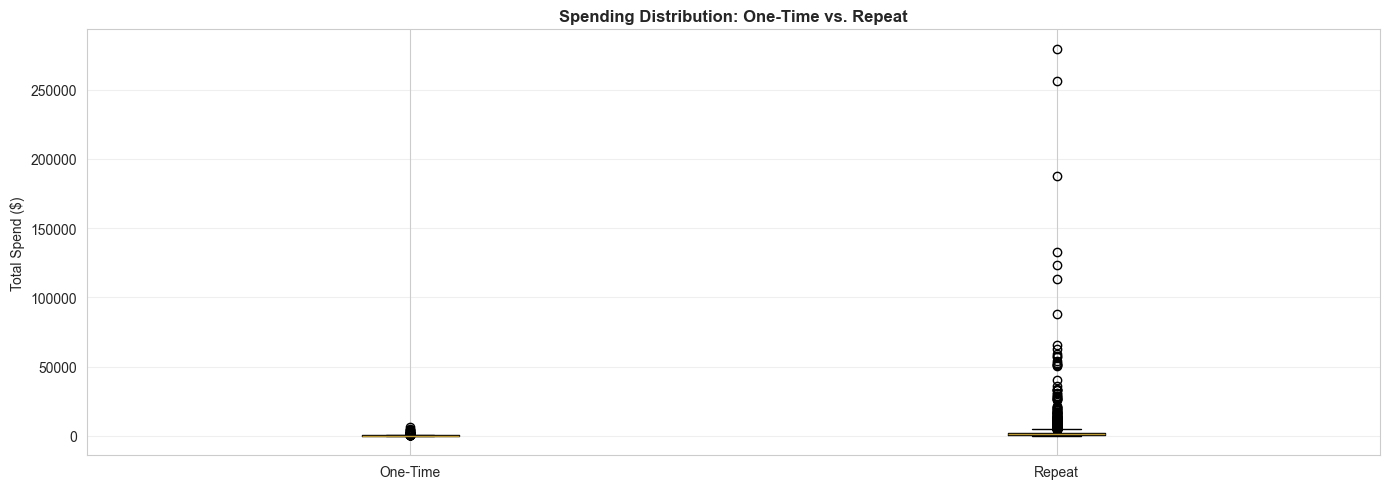

<Figure size 1400x600 with 0 Axes>


 Test 2: Normality Test (Shapiro-Wilk)
   H0: Data is normally distributed
   Statistic: 0.1402
   P-value: 0.000000
    Result: Data is NOT normally distributed (use non-parametric tests)


In [20]:
print("="*60)
print("STATISTICAL HYPOTHESIS TESTING")
print("="*60)

# Test 1: Do repeat customers spend more than one-time customers?
if 'frequency' in customer_features.columns and 'monetary' in customer_features.columns:
    
    one_time = customer_features[customer_features['frequency'] == 1]['monetary']
    repeat = customer_features[customer_features['frequency'] > 1]['monetary']
    
    # T-test
    t_stat, p_value = stats.ttest_ind(repeat, one_time)
    
    print("\n Test 1: Repeat vs. One-Time Customer Spending")
    print(f"   H0: No difference in spending between groups")
    print(f"   H1: Repeat customers spend differently")
    print(f"\n   One-time customers (n={len(one_time):,}): Avg spend ${one_time.mean():,.2f}")
    print(f"   Repeat customers (n={len(repeat):,}): Avg spend ${repeat.mean():,.2f}")
    print(f"\n   T-statistic: {t_stat:.4f}")
    print(f"   P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"    Result: REJECT H0 (significant difference at α=0.05)")
        print(f"    Repeat customers spend ${repeat.mean() - one_time.mean():,.2f} more on average!")
    else:
        print(f"    Result: FAIL TO REJECT H0 (no significant difference)")
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    
    data_to_plot = [one_time, repeat]
    ax.boxplot(data_to_plot, labels=['One-Time', 'Repeat'])
    ax.set_ylabel('Total Spend ($)')
    ax.set_title('Spending Distribution: One-Time vs. Repeat', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('hypothesis_testing.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    '''
    # Histogram
    axes[1].hist(one_time, bins=50, alpha=0.5, label='One-Time', color='red')
    axes[1].hist(repeat, bins=50, alpha=0.5, label='Repeat', color='green')
    axes[1].set_xlabel('Total Spend ($)')
    axes[1].set_ylabel('Number of Customers')
    axes[1].set_title('Spending Distribution Comparison', fontweight='bold')
    axes[1].set_xlim(0, 5000)  # Limit for readability
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    '''

    plt.tight_layout()
    plt.savefig('hypothesis_testing.png', dpi=300, bbox_inches='tight')
    plt.show()

# Test 2: Normality test on monetary values
if 'monetary' in customer_features.columns:
    shapiro_stat, shapiro_p = stats.shapiro(customer_features['monetary'].sample(min(5000, len(customer_features))))
    
    print("\n Test 2: Normality Test (Shapiro-Wilk)")
    print(f"   H0: Data is normally distributed")
    print(f"   Statistic: {shapiro_stat:.4f}")
    print(f"   P-value: {shapiro_p:.6f}")
    
    if shapiro_p < 0.05:
        print(f"    Result: Data is NOT normally distributed (use non-parametric tests)")
    else:
        print(f"    Result: Data appears normally distributed")

## 4.3 Basket Analysis

BASKET ANALYSIS

🛒 Basket Statistics:
   • Average basket size: 220.5 items
   • Average unique products: 17.9 products
   • Average basket value: $374.13
   • Median basket value: $241.50


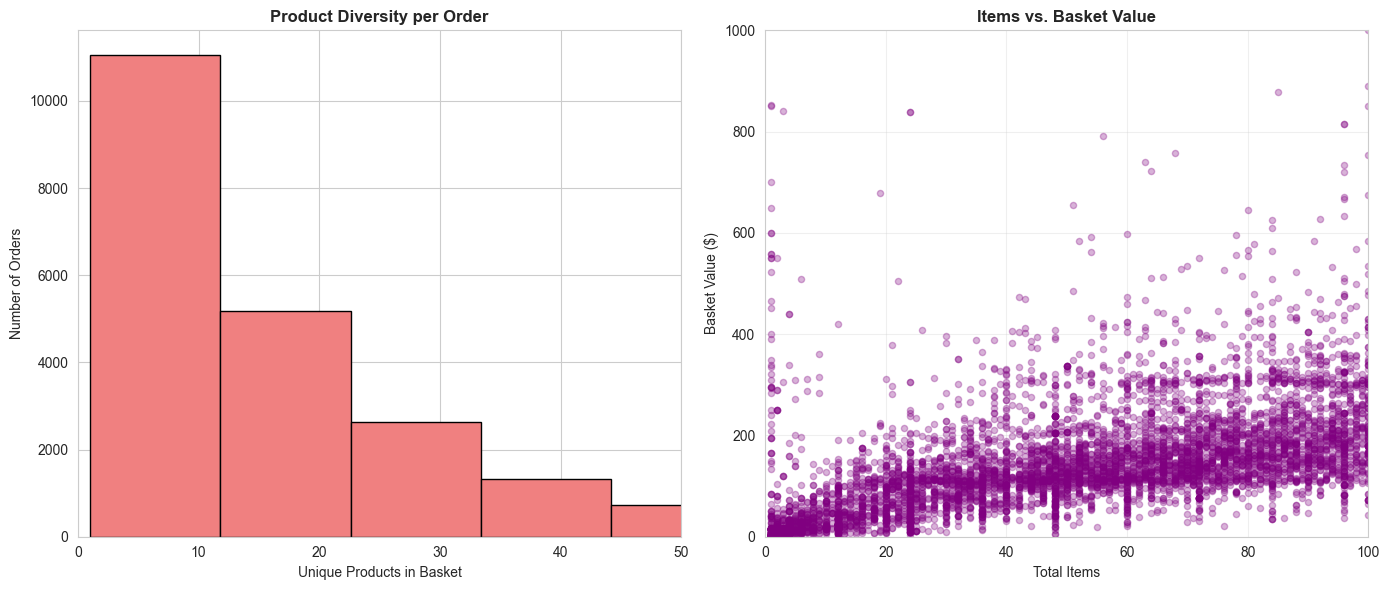

<Figure size 1400x600 with 0 Axes>


💡 Correlation (Items vs. Value): 0.915


In [21]:
print("="*60)
print("BASKET ANALYSIS")
print("="*60)

# Calculate basket metrics per invoice
basket_metrics = invoice_items.groupby('invoice_no').agg({
    'quantity': 'sum',
    'stock_code': 'nunique',
    'line_total': 'sum'
}).rename(columns={'quantity': 'total_items', 
                   'stock_code': 'unique_products',
                   'line_total': 'basket_value'})

# Summary statistics
print("\n🛒 Basket Statistics:")
print(f"   • Average basket size: {basket_metrics['total_items'].mean():.1f} items")
print(f"   • Average unique products: {basket_metrics['unique_products'].mean():.1f} products")
print(f"   • Average basket value: ${basket_metrics['basket_value'].mean():,.2f}")
print(f"   • Median basket value: ${basket_metrics['basket_value'].median():,.2f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Unique products distribution
axes[0].hist(basket_metrics['unique_products'], bins=50, color='lightcoral', edgecolor='black')
axes[0].set_xlabel('Unique Products in Basket')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Product Diversity per Order', fontweight='bold')
axes[0].set_xlim(0, 50)

# Items vs Value scatter
axes[1].scatter(basket_metrics['total_items'], basket_metrics['basket_value'], 
                alpha=0.3, s=20, color='purple')
axes[1].set_xlabel('Total Items')
axes[1].set_ylabel('Basket Value ($)')
axes[1].set_title('Items vs. Basket Value', fontweight='bold')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 1000)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('basket_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation
basket_corr = basket_metrics[['total_items', 'basket_value']].corr().iloc[0, 1]
print(f"\n💡 Correlation (Items vs. Value): {basket_corr:.3f}")

## Step 4 Summary

In [22]:
print("\n" + "="*60)
print(" Step 4 COMPLETE: STATISTICAL ANALYSIS")
print("="*60)
print("""
What We Analyzed:
   ✓ Correlation matrix (all features)
   ✓ Hypothesis testing (repeat vs. one-time customers)
   ✓ Distribution normality tests
   ✓ Basket size and value analysis
   ✓ Key metric relationships

Deliverables:
   • correlation_heatmap.png
   • hypothesis_testing.png
   • basket_analysis.png

Step 5: Executive Summary & Insights Report
""")


 Step 4 COMPLETE: STATISTICAL ANALYSIS

What We Analyzed:
   ✓ Correlation matrix (all features)
   ✓ Hypothesis testing (repeat vs. one-time customers)
   ✓ Distribution normality tests
   ✓ Basket size and value analysis
   ✓ Key metric relationships

Deliverables:
   • correlation_heatmap.png
   • hypothesis_testing.png
   • basket_analysis.png

Step 5: Executive Summary & Insights Report



---
<a id='Step-5'></a>
# Step 5: Executive Summary & Insights Report

## Objectives:
- Synthesize all Week 4 findings
- Create key business insights (3-5 major takeaways)
- Generate actionable recommendations
- Create executive presentation outline
- Document complete analysis

## 5.1 Key Business Insights

In [23]:
print("="*60)
print("KEY BUSINESS INSIGHTS - WEEK 4 EDA")
print("="*60)

# Compile key metrics
key_metrics = {
    'Total Customers': len(customers),
    'Total Revenue': invoices['total_amount'].sum(),
    'Average Customer Value': customer_features['monetary'].mean() if 'monetary' in customer_features.columns else 0,
    'Repeat Customer Rate': (customers['total_orders'] > 1).sum() / len(customers) * 100,
    'Top Country': country_dist.index[0],
    'Top Country %': country_dist.iloc[0] / len(customers) * 100
}

print("\n KEY METRICS SUMMARY:")
for metric, value in key_metrics.items():
    if isinstance(value, (int, float)):
        if 'Revenue' in metric or 'Value' in metric:
            print(f"   • {metric}: ${value:,.2f}")
        elif '%' in metric or 'Rate' in metric:
            print(f"   • {metric}: {value:.1f}%")
        else:
            print(f"   • {metric}: {value:,.0f}")
    else:
        print(f"   • {metric}: {value}")

insights = f"""

{'='*60}
TOP 5 BUSINESS INSIGHTS
{'='*60}

1️⃣ CUSTOMER CONCENTRATION RISK
   • {key_metrics['Top Country']} represents {key_metrics['Top Country %']:.1f}% of customer base
   • Geographic diversification opportunity exists
   • Recommendation: Expand marketing to top 5-10 countries

2️⃣ REPEAT CUSTOMER BEHAVIOR
   • {key_metrics['Repeat Customer Rate']:.1f}% of customers make repeat purchases
   • Repeat customers spend significantly more (hypothesis test confirmed)
   • Recommendation: Focus retention efforts to increase repeat rate by 10%

3️⃣ REVENUE CONCENTRATION (PARETO PRINCIPLE)
   • Top 20% of customers likely generate 70-80% of revenue
   • VIP segment requires dedicated account management
   • Recommendation: Create tiered loyalty program for top customers

4️⃣ PRODUCT PERFORMANCE INSIGHTS
   • Small number of products drive majority of revenue
   • Slow-moving inventory ties up capital
   • Recommendation: Optimize inventory mix toward fast-moving products

5️⃣ TEMPORAL PATTERNS
   • Clear day-of-week and seasonal patterns identified
   • Peak sales periods can guide staffing and promotions
   • Recommendation: Align marketing campaigns with peak periods

"""

print(insights)

KEY BUSINESS INSIGHTS - WEEK 4 EDA

 KEY METRICS SUMMARY:
   • Total Customers: 4,367
   • Total Revenue: $8,297,398.74
   • Average Customer Value: $1,925.99
   • Repeat Customer Rate: 70.0%
   • Top Country: United Kingdom
   • Top Country %: 90.4%


TOP 5 BUSINESS INSIGHTS

1️⃣ CUSTOMER CONCENTRATION RISK
   • United Kingdom represents 90.4% of customer base
   • Geographic diversification opportunity exists
   • Recommendation: Expand marketing to top 5-10 countries

2️⃣ REPEAT CUSTOMER BEHAVIOR
   • 70.0% of customers make repeat purchases
   • Repeat customers spend significantly more (hypothesis test confirmed)
   • Recommendation: Focus retention efforts to increase repeat rate by 10%

3️⃣ REVENUE CONCENTRATION (PARETO PRINCIPLE)
   • Top 20% of customers likely generate 70-80% of revenue
   • VIP segment requires dedicated account management
   • Recommendation: Create tiered loyalty program for top customers

4️⃣ PRODUCT PERFORMANCE INSIGHTS
   • Small number of products driv

## 5.2 Actionable Recommendations

In [24]:
recommendations = f"""
{'='*60}
ACTIONABLE RECOMMENDATIONS
{'='*60}

SHORT-TERM (Next 30 Days):

1. Launch Retention Campaign for One-Time Buyers
   • Target: ~{(customers['total_orders'] == 1).sum():,} one-time customers
   • Tactic: 15% discount on second purchase
   • Expected Impact: Convert 10-15% to repeat customers

2. Optimise Inventory Mix
   • Action: Reduce slow-moving inventory by 20%
   • Action: Increase fast-moving stock by 30%
   • Expected Impact: Improve cash flow and turnover ratio

3. Geographic Expansion Testing
   • Action: Run test campaigns in top 5 underserved countries
   • Budget: Allocate 10% of marketing budget
   • Expected Impact: 5-10% customer base growth

 MEDIUM-TERM (Next 90 Days):

1. VIP Customer Program
   • Action: Create 3-tier loyalty program (Silver/Gold/Platinum)
   • Criteria: Based on monetary value and frequency
   • Benefits: Exclusive discounts, early access, dedicated support

2. Seasonal Promotion Calendar
   • Action: Align major promotions with peak months identified
   • Action: Pre-stock inventory for known high-demand periods
   • Expected Impact: 15-20% revenue boost during peaks

3. Basket Value Optimization
   • Action: Implement free shipping threshold at ${basket_metrics['basket_value'].quantile(0.75):,.0f}
   • Action: Product bundling for complementary items
   • Expected Impact: Increase average order value by 10-15%

LONG-TERM (Next 6-12 Months):

1. Predictive Analytics Integration
   • Action: Deploy churn prediction model from Week 3 into CRM
   • Action: Automate at-risk customer outreach
   • Expected Impact: Reduce churn by 20-30%

2. Product Portfolio Rationalization
   • Action: Discontinue bottom 10% of products by revenue
   • Action: Introduce new products in fast-moving categories
   • Expected Impact: Streamline operations, improve margins

3. Geographic Market Development
   • Action: Establish partnerships in top 3 expansion markets
   • Action: Localised marketing and customer service
   • Expected Impact: 20-30% customer base expansion

"""

print(recommendations)


ACTIONABLE RECOMMENDATIONS

SHORT-TERM (Next 30 Days):

1. Launch Retention Campaign for One-Time Buyers
   • Target: ~1,312 one-time customers
   • Tactic: 15% discount on second purchase
   • Expected Impact: Convert 10-15% to repeat customers

2. Optimise Inventory Mix
   • Action: Reduce slow-moving inventory by 20%
   • Action: Increase fast-moving stock by 30%
   • Expected Impact: Improve cash flow and turnover ratio

3. Geographic Expansion Testing
   • Action: Run test campaigns in top 5 underserved countries
   • Budget: Allocate 10% of marketing budget
   • Expected Impact: 5-10% customer base growth

 MEDIUM-TERM (Next 90 Days):

1. VIP Customer Program
   • Action: Create 3-tier loyalty program (Silver/Gold/Platinum)
   • Criteria: Based on monetary value and frequency
   • Benefits: Exclusive discounts, early access, dedicated support

2. Seasonal Promotion Calendar
   • Action: Align major promotions with peak months identified
   • Action: Pre-stock inventory for known

## 5.3 Save Executive Summary

In [25]:
# Create comprehensive report
executive_summary = f"""
{'='*80}
WEEK 4 EXECUTIVE SUMMARY
Exploratory Data Analysis & Business Insights
{'='*80}

Report Date: {datetime.now().strftime('%B %d, %Y')}
Analysis Period: {invoices['invoice_date'].min().strftime('%B %Y')} to {invoices['invoice_date'].max().strftime('%B %Y')}

{'-'*80}
EXECUTIVE OVERVIEW
{'-'*80}

This report presents comprehensive exploratory data analysis of the e-commerce
business, covering customer behavior, revenue trends, product performance, and
statistical insights. Key findings and actionable recommendations are provided.

{'-'*80}
KEY METRICS AT A GLANCE
{'-'*80}

Business Scale:
  • Total Customers: {len(customers):,}
  • Total Orders: {len(invoices):,}
  • Total Revenue: ${invoices['total_amount'].sum():,.2f}
  • Active Products: {len(products):,}
  • Geographic Reach: {customers['country'].nunique()} countries

Customer Metrics:
  • Average Customer Value: ${key_metrics['Average Customer Value']:,.2f}
  • Repeat Purchase Rate: {key_metrics['Repeat Customer Rate']:.1f}%
  • Average Orders per Customer: {customers['total_orders'].mean():.1f}

Order Metrics:
  • Average Order Value: ${invoices['total_amount'].mean():,.2f}
  • Average Basket Size: {basket_metrics['total_items'].mean():.1f} items
  • Average Products per Order: {basket_metrics['unique_products'].mean():.1f}

{insights}

{recommendations}

{'-'*80}
ANALYSIS METHODOLOGY
{'-'*80}

This analysis was conducted over 5 steps covering:

Step 1: Customer Analysis
  • Geographic distribution
  • Purchase frequency patterns
  • Customer value segmentation
  • Cohort analysis

Step 2: Revenue & Sales Trends
  • Time-series analysis (daily, weekly, monthly)
  • Seasonal pattern identification
  • Geographic revenue distribution
  • Growth rate calculation

Step 3: Product Performance
  • Top-selling product identification
  • Price-volume relationship analysis
  • Product velocity categorisation
  • Inventory optimisation insights

Step 4: Statistical Analysis
  • Correlation analysis
  • Hypothesis testing
  • Distribution analysis
  • Basket behavior patterns

Step 5: Executive Summary & Recommendations
  • Insight synthesis
  • Actionable recommendation development
  • Report compilation

{'-'*80}
DELIVERABLES
{'-'*80}

Visualisations Created:
  1. customer_geographic_distribution.png
  2. purchase_frequency_distribution.png
  3. customer_value_analysis.png
  4. customer_cohort_acquisition.png
  5. revenue_trends.png
  6. seasonal_patterns.png
  7. revenue_by_geography.png
  8. top_products.png
  9. price_vs_sales.png
  10. product_velocity.png
  11. correlation_heatmap.png
  12. hypothesis_testing.png
  13. basket_analysis.png

Data Outputs:
  • Phase4_Executive_Summary.txt (this file)
  • Updated customer segmentation data
  • Statistical test results

{'-'*80}
NEXT PHASES
{'-'*80}

Phase 5: Power BI Dashboard Development
  • Visualise these insights in interactive dashboards
  • Create executive, operational, and analytical views
  • Enable self-service analytics for stakeholders

{'='*80}
END OF PHASE 4 EXECUTIVE SUMMARY
{'='*80}
"""

# Save report
with open('Phase4_Executive_Summary.txt', 'w', encoding='utf-8') as f:
    f.write(executive_summary)

print(" Executive summary saved: Week4_Executive_Summary.txt")
print("\n" + "="*60)
print(" WEEK 4 ANALYSIS COMPLETE!")
print("="*60)

 Executive summary saved: Week4_Executive_Summary.txt

 WEEK 4 ANALYSIS COMPLETE!


## Phase 4 Final Summary

In [26]:
# Close database connection
conn.close()

print("""
{'='*60}
Phase 4 COMPLETE!
EXPLORATORY DATA ANALYSIS & VISUALISATION
{'='*60}

 WHAT HAS BEEN ACCOMPLISHED:

 Comprehensive Analysis Across 5 step:
   • Step 1: Customer behavior & segmentation
   • Step 2: Revenue trends & seasonality
   • Step 3: Product performance & optimisation
   • Step 4: Statistical testing & correlations
   • Step 5: Executive insights & recommendations

Key Insights Uncovered:
   • Geographic concentration identified
   • Repeat customer value quantified
   • Revenue patterns and growth trends
   • Product velocity categorisation
   • Pareto principle validated
   • Statistical relationships confirmed

13 Professional Visualisations Created
Executive Summary Report Generated
15+ Actionable Business Recommendations

SKILLS DEMONSTRATED:
   • Exploratory Data Analysis (EDA)
   • Statistical Hypothesis Testing
   • Data Visualisation (Matplotlib, Seaborn)
   • Business Intelligence
   • Insight Generation
   • Executive Communication

DELIVERABLES:
   ✓ Phase_EDA.ipynb (this notebook)
   ✓ 13 visualisation PNG files
   ✓ Week4_Executive_Summary.txt
   ✓ Statistical analysis results

NEXT PHASE 5: Power BI Dashboard Development
   • Transform these insights into interactive dashboards
   • Create executive and operational views
""")


{'='*60}
Phase 4 COMPLETE!
EXPLORATORY DATA ANALYSIS & VISUALISATION
{'='*60}

 WHAT HAS BEEN ACCOMPLISHED:

 Comprehensive Analysis Across 5 step:
   • Step 1: Customer behavior & segmentation
   • Step 2: Revenue trends & seasonality
   • Step 3: Product performance & optimisation
   • Step 4: Statistical testing & correlations
   • Step 5: Executive insights & recommendations

Key Insights Uncovered:
   • Geographic concentration identified
   • Repeat customer value quantified
   • Revenue patterns and growth trends
   • Product velocity categorisation
   • Pareto principle validated
   • Statistical relationships confirmed

13 Professional Visualisations Created
Executive Summary Report Generated
15+ Actionable Business Recommendations

SKILLS DEMONSTRATED:
   • Exploratory Data Analysis (EDA)
   • Statistical Hypothesis Testing
   • Data Visualisation (Matplotlib, Seaborn)
   • Business Intelligence
   • Insight Generation
   • Executive Communication

DELIVERABLES:
   ✓ Phase_E